# The ECB Announcement Effect — a quantitative teardown 🔬
### Decision-day Welch/HAC splits · a two-sided random-calendar placebo · the [−5..+3] Lucca-Moench-style event anatomy · the EURUSD cross-check · the 2015 cadence-era contrast · an honest "costs on a timer" test · a 20-seed synthetic null

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Louder_not_more_directional%3F: Confirmed](https://img.shields.io/badge/Louder_not_more_directional%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **euro-area equities react systematically around ECB Governing Council decisions** — is the ECB's own version of the Fed folklore this desk already tested twice ([637](../../637-fomc-vol-crush/), [517](../../517-pre-fomc-drift/)). The job here is to measure it honestly on the ECB's own calendar, then ask the only question that pays: *is any of it tradable?*

> ⚠️ **Data note.** FEZ raw OHLC + EURUSD=X OHLC (2005→2026), yfinance, cached; **208 hardcoded scheduled ECB decision dates** from the ECB's own year-ahead schedule press releases (2005-2014, monthly) and statement archive (2015-2026, 6-week cycle); 207 land on the FEZ tape (the scheduled 2013-07-04 decision fell on a US market holiday, named quirk). No survivorship (baskets/rates, not a panel). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `d1fc0178e274` / `c85271b5a68f`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ecb_announcement_effect import data, strategy as st

ECB = data.ecb_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    FEZ, EURUSD = data.load_real()
    DF = st.day_frame(FEZ, EURUSD, ECB)
else:
    FEZ = EURUSD = DF = None
print("real cache present:", HAVE_REAL, "| scheduled ECB decisions:", len(ECB),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'n_ecb': 207, 'n_rest': 5198, 'n_calendar': 208, 'cal_lo': '2005-01-13', 'cal_hi': '2026-06-11', 'ecb_pct': -0.103, 'rest_pct': 0.015, 'gap_pct': -0.118, 'welch_t': -0.82, 'nw_t': -0.83, 'hit': 114, 'hit_pct': 55.1, 'wilson': (48.3, 61.7), 'placebo_p': 0.345, 'placebo_mean': 0.0141, 'placebo_sd': 0.1093, 'placebo_draws': 20000, 'rng_ecb': 1.492, 'rng_rest': 1.257, 'rng_ratio': 1.19, 'rng_welch_t': 2.66, 'rng_nw_t': 2.83, 'rng_placebo_p': 0.0008, 'fx_ecb': 0.455, 'fx_rest': 0.436, 'fx_t': 0.65, 'event': {-5: (0.105, 0.85), -4: (-0.099, -1.1), -3: (-0.203, -1.58), -2: (0.171, 1.23), -1: (0.146, 1.11), 0: (-0.103, -0.84), 1: (0.017, -0.01), 2: (-0.112, -0.91), 3: (0.032, 0.12)}, 'runup_pct': 0.121, 'runup_t': 0.54, 'era_early': -0.137, 'era_early_n': 115, 'era_early_t': -0.66, 'era_late': -0.061, 'era_late_n': 92, 'era_late_t': -0.46, 'era_diff_t': 0.27, 'rng_era_early': 1.722, 'rng_era_early_t': 1.7, 'rng_era_late': 1.206, 'rng_era_late_t': 1.65, 'rng_era_diff_t': -3.18, 'tm_gross': -10.3, 'tm_net5': -20.3, 'tm_net10': -30.3, 'tm_net20': -50.3, 'tm_rest': 1.5, 'tm_t': -0.82, 'tm_ann5': -1.62, 'tm_ann10': -2.42, 'tm_ann20': -4.02, 'tm_n': 207, 'tm_hit': 55.1, 'tm_worst': -13.3, 'syn_null_mean': -0.07, 'syn_null_sd': 0.73, 'syn_null_fire': 0, 'syn_planted_t': 7.48, 'fp_fez': 'd1fc0178e274', 'fp_eurusd': 'c85271b5a68f'}


real cache present: True | scheduled ECB decisions: 208 | tape days: 5405


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | drift: Welch **t = -0.82**, NW **t = -0.83**, placebo **p = 0.345** — none. range: **1.19×**, Welch **t = 2.66**, NW **t = 2.83**, placebo **p = 0.0008** — real |
| **Tradability** | `MIRAGE` | timer rule gross **-10.3 bps/event** (before costs), worst day **-13.3%** |
| **Louder, not more directional?** | `CONFIRMED` | range real (*t* ≥ 2.66), direction (*t* = -0.82) and EURUSD reaction (*t* = 0.65) both null |

> 💡 In plain words: the ECB genuinely turns up the volume on decision day; it just never tells you which way the needle will swing.

## 1 · The claim, steelmanned

Let $r_t$ be FEZ's daily close-to-close log return and $D_t \in \{0,1\}$ the scheduled-decision-day flag (known *ex ante* — the calendar is published months ahead). The decision lands at 13:45 CET, the press conference at 14:30/14:15 CET — both well before FEZ's US-market close — so the decision-day bar should contain the reaction. The claims:

- **H₁ (drift).** $E[r_t \mid D_t=1] \ne E[r_t \mid D_t=0]$ — a systematic directional move, large enough to clear noise.
- **H₂ (loud, not calm).** Realized FEZ range on decision days exceeds the baseline — a genuine reaction is visible even without a signed direction.
- **H₃ (FX cross-check).** EURUSD's absolute move is larger on decision days — the currency, pricing the policy surprise most directly, should react too.
- **H₄ (anatomy).** A Lucca-Moench-style pre-meeting run-up and a post-day persistence pattern.
- **H₅ (capture).** A calendar timing rule (FEZ, decision day only) banks the effect net of costs.

We find **H₁ NOT supported** (drift indistinguishable from noise), **H₂ supported** (range *t* ≥ 2.66 three ways), **H₃ NOT supported** (EURUSD *t* = 0.65), **H₄ NOT supported** (every event-window offset |*t*| < 1.6), **H₅ NOT supported** (negative gross before costs).

## 2 · So what? — inference design

Decision days are **single, non-overlapping events**, so the planned primary is a **Welch t** on the group split. Because realized range is strongly serially correlated (vol clustering), the **Newey-West (5-lag) t** on the dummy regression is the load-bearing robustness check for H₂, not a formality — a naive Welch split on an autocorrelated series can overstate significance, and we want the bar cleared on both. A two-sided **20,000-draw random-calendar placebo** (20 seeds × 1,000 draws) checks both H₁ and H₂ against "could a random 207-day calendar have looked this good", and the 2015 cadence-era split (justified *ex ante* — the Governing Council's own July-2014 announcement) is tested as a **difference**, not eyeballed.

## 3 · How we'd know — the protocol

- **Calendar.** 208 scheduled decisions 2005-01-13 → 2026-06-11, hardcoded (ECB schedule press releases + statement archive); 207 land on the FEZ tape (one US-holiday collision, named).
- **Tape.** FEZ raw OHLC + EURUSD=X OHLC 2005-01-03 → 2026-06-30. As-of 2026-06-30 (last complete month).
- **Headline.** Welch t + NW(5) t + two-sided 20-seed placebo, on both the return (drift) and the range (loudness).
- **Cross-check.** EURUSD |return| split on the same days.
- **Anatomy.** Event window [−5..+3], per-offset Welch t vs far days; cumulative run-up per meeting, one-sample t.
- **Execution (third axis).** Enter FEZ at the prior close (calendar public — zero look-ahead), exit the decision close; 2 × one-way cost × NAV per event; long-only, no borrow.
- **Control.** Synthetic i.i.d.-return world, planted drift knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its placebo — the drift

Welch t on FEZ log return (decision vs rest), NW t on the dummy regression, and the random-calendar null. In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

ECB-day FEZ return -0.103%  vs  other +0.015%
Welch t = -0.82   NW(5) t = -0.83
hit 114/207 = 55.1%  Wilson [48.3%, 61.7%]


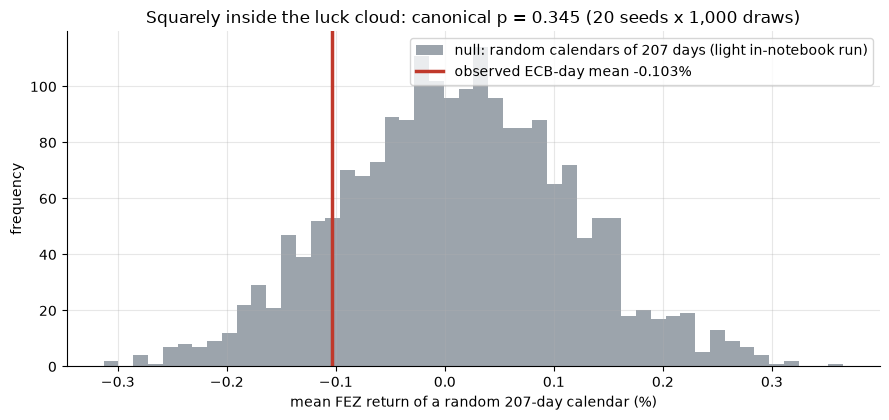

canonical placebo (results.md): mean +0.0141%, sd 0.1093%, p = 0.345


In [2]:
if HAVE_REAL:
    s = st.decision_day_stats(DF)
    print(f"ECB-day FEZ return {s['ecb_pct']:+.3f}%  vs  other {s['rest_pct']:+.3f}%")
    print(f"Welch t = {s['welch_t']:+.2f}   NW(5) t = {s['nw_t']:+.2f}")
    print(f"hit {s['hit_up']}/{s['n_ecb']} = {s['hit_rate']*100:.1f}%  "
          f"Wilson [{s['hit_lo']*100:.1f}%, {s['hit_hi']*100:.1f}%]")
    pl = st.placebo_pvalue(DF, column='fez_ret', n_draws_per_seed=500, n_seeds=4)
    obs, draws = pl['obs'], pl['draws']
else:
    obs = R['ecb_pct'] / 100
    rng = np.random.default_rng(645)
    draws = rng.normal(R['placebo_mean']/100, R['placebo_sd']/100, 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.85,
        label='null: random calendars of 207 days (light in-notebook run)')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed ECB-day mean {obs*100:+.3f}%')
ax.set_xlabel('mean FEZ return of a random 207-day calendar (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Squarely inside the luck cloud: canonical p = {R['placebo_p']:.3f} "
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.4f}%, "
      f"sd {R['placebo_sd']:.4f}%, p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed **-0.103%** sits well inside the null's spread (+0.0141% ± 0.1093%); **p = 0.345** — about a third of random calendars do as well or better. Welch t = **-0.82** and NW t = **-0.83** agree: H₁ (drift) is not supported.

### 4b · The realized-range cross-check — loudness IS real

Same machinery, applied to (H−L)/prev-close instead of the signed return. Range is strongly autocorrelated (volatility clusters), so the NW cross-check is the one that actually decides this cell.

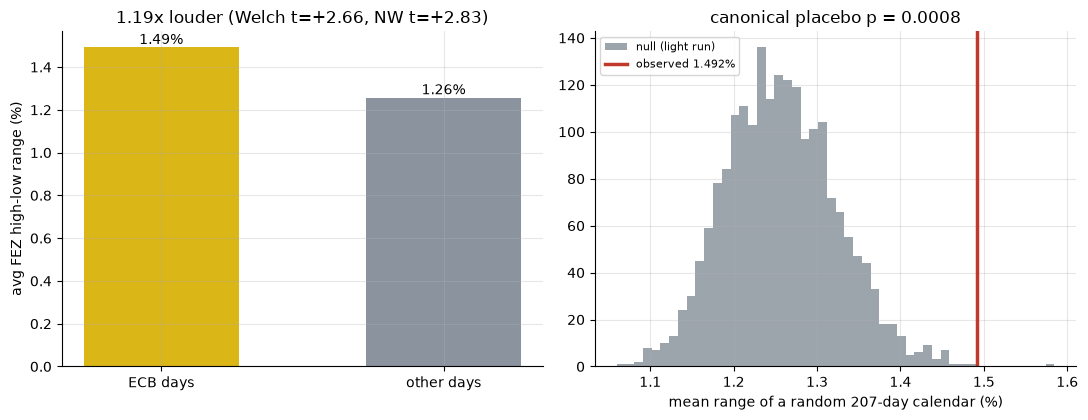

range: ECB 1.492% vs other 1.257% (1.19x)  Welch t=+2.66  NW t=+2.83


In [3]:
if HAVE_REAL:
    rg = st.range_stats(DF)
    a, b, ratio, tw, tnw = (rg['ecb_range_pct'], rg['rest_range_pct'], rg['ratio'],
                            rg['welch_t'], rg['nw_t'])
    pr = st.placebo_pvalue(DF, column='fez_range', n_draws_per_seed=500, n_seeds=4)
    draws_r = pr['draws']
else:
    a, b, ratio, tw, tnw = (R['rng_ecb'], R['rng_rest'], R['rng_ratio'],
                            R['rng_welch_t'], R['rng_nw_t'])
    rng2 = np.random.default_rng(645)
    draws_r = rng2.normal(R['rng_rest']/100, 0.007, 2000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['ECB days','other days'], [a, b], color=[AMBER, GREY], width=.55)
for i,v in enumerate([a, b]): a1.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('avg FEZ high-low range (%)')
a1.set_title(f'{ratio:.2f}x louder (Welch t={tw:+.2f}, NW t={tnw:+.2f})')
a2.hist(draws_r*100, bins=50, color=GREY, alpha=.85, label='null (light run)')
a2.axvline(a, c=RED, lw=2.5, label=f'observed {a:.3f}%')
a2.set_xlabel('mean range of a random 207-day calendar (%)')
a2.set_title(f"canonical placebo p = {R['rng_placebo_p']:.4f}")
a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'range: ECB {a:.3f}% vs other {b:.3f}% ({ratio:.2f}x)  '
      f'Welch t={tw:+.2f}  NW t={tnw:+.2f}')

> 💡 In plain words: FEZ's high-low swing runs **1.19×** normal on decision day, and it clears *t* ≥ 2 **three** separate ways — raw Welch (**2.66**), the autocorrelation-robust NW cross-check (**2.83**), and a two-sided placebo (**p = 0.0008**). H₂ is genuinely supported — this is the one real signal in the study.

### 4c · The EURUSD cross-check — the FX leg doesn't react more either

If the decision were moving markets hard, the currency — which prices the policy surprise most directly — should be the first place to see it.

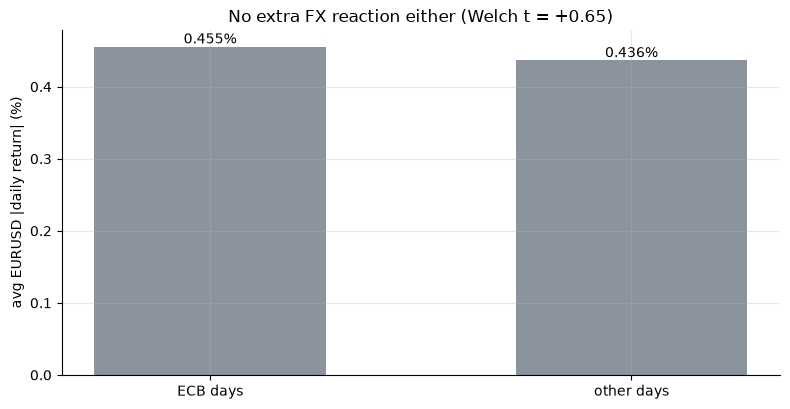

EURUSD |return|: ECB 0.455%  vs other 0.436%   Welch t = +0.65


In [4]:
if HAVE_REAL:
    fx = st.eurusd_stats(DF)
    a, b, t = fx['ecb_abs_pct'], fx['rest_abs_pct'], fx['welch_t']
else:
    a, b, t = R['fx_ecb'], R['fx_rest'], R['fx_t']
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['ECB days','other days'], [a, b], color=[GREY, GREY], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('avg EURUSD |daily return| (%)')
ax.set_title(f'No extra FX reaction either (Welch t = {t:+.2f})')
plt.tight_layout(); plt.show()
print(f'EURUSD |return|: ECB {a:.3f}%  vs other {b:.3f}%   Welch t = {t:+.2f}')

> 💡 In plain words: EURUSD's absolute move on decision day (0.455%) is statistically the same as any other day (0.436%, *t* = 0.65). H₃ is not supported — whatever the FEZ range bump picks up, it isn't a proportionally larger currency shock.

### 4d · Anatomy — a Lucca-Moench-style event window

Per-offset means with Welch t vs far-from-meeting days; the run-up is tested as a **cumulative per-meeting** quantity (one-sample t across 207 meetings).

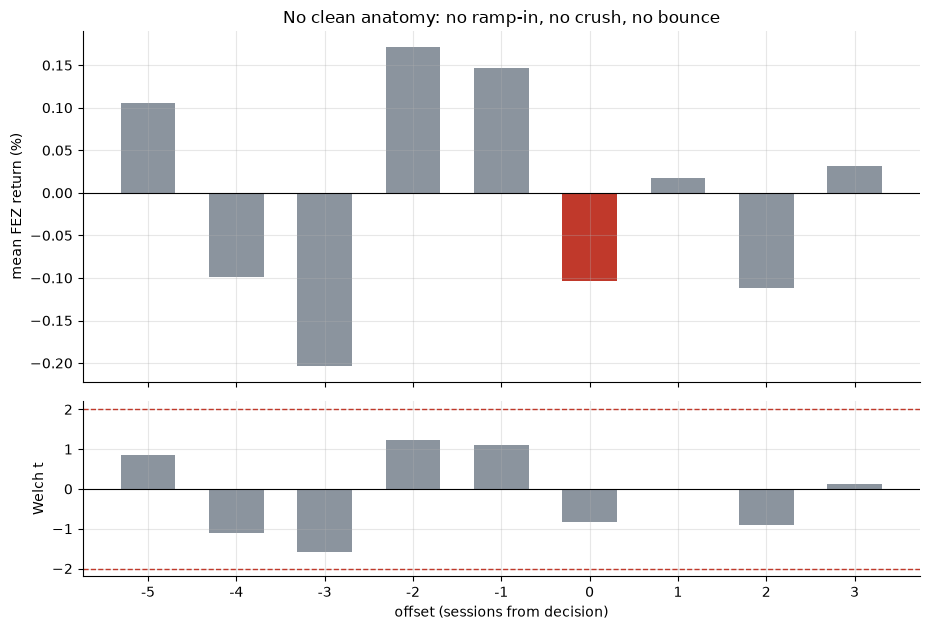

cumulative run-up [-5..-1]: +0.121%/meeting (t = +0.54)


In [5]:
if HAVE_REAL:
    ev = st.event_study(DF, ECB)
    ks = list(ev.index); ms = list(ev['mean_pct']); ts = list(ev['welch_t'])
    ru = st.runup_stats(DF, ECB)
    ru_m, ru_t = ru['mean_runup_pct'], ru['t']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    ts = [R['event'][k][1] for k in ks]; ru_m, ru_t = R['runup_pct'], R['runup_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k==0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean FEZ return (%)')
a1.set_title('No clean anatomy: no ramp-in, no crush, no bounce')
a2.bar([str(k) for k in ks], ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); a2.set_xlabel('offset (sessions from decision)')
plt.tight_layout(); plt.show()
print(f'cumulative run-up [-5..-1]: {ru_m:+.3f}%/meeting (t = {ru_t:+.2f})')

> 💡 In plain words: every single offset in the nine-day window sits below |*t*| = 1.6. The pre-meeting run-up (**+0.12%/meeting**, *t* = 0.54) shows no trace of a Lucca-Moench-style build-up, and day 0 (**-0.103%**, *t* = -0.84) isn't even the largest bar in the window — day −3 is bigger in magnitude. H₄ is not supported.

### 4e · The era contrast — justified split, tested as a difference

Split at **2015-01-01** (the Governing Council's own move to the 6-week cycle, announced 2014-07; chosen ex ante, not snooped). Applied to both the return (already-null) and the range (the one real effect).

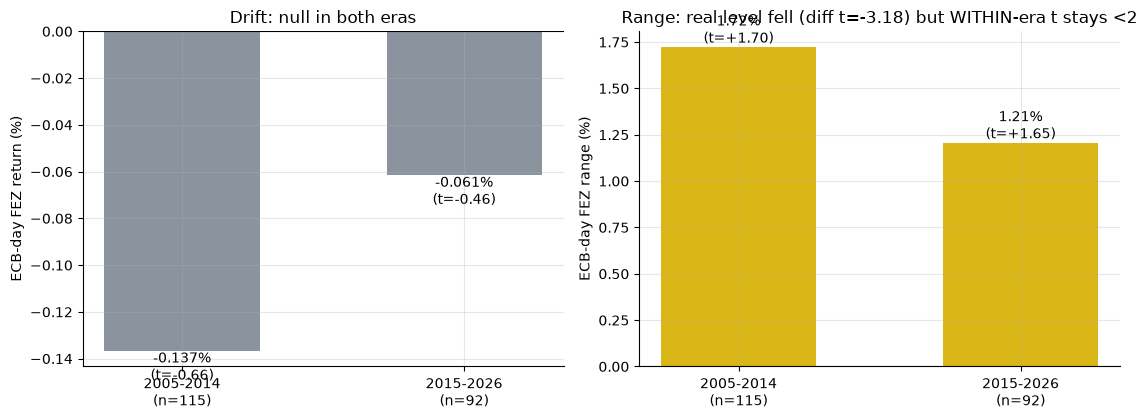

return: early -0.137 (t=-0.66)  late -0.061 (t=-0.46)  diff t=+0.27
range:  early 1.722 (t=+1.70)  late 1.206 (t=+1.65)  diff t=-3.18


In [6]:
if HAVE_REAL:
    ec = st.era_contrast(DF, data.SIXWEEK_SPLIT, column='fez_ret')
    ecr = st.era_contrast(DF, data.SIXWEEK_SPLIT, column='fez_range')
    e, l = ec['early_pct'], ec['late_pct']
    et, lt, dt = ec['welch_t_early'], ec['welch_t_late'], ec['welch_t_diff']
    re, rl = ecr['early_pct'], ecr['late_pct']
    ret_, rlt, rdt = ecr['welch_t_early'], ecr['welch_t_late'], ecr['welch_t_diff']
else:
    e, l = R['era_early'], R['era_late']
    et, lt, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
    re, rl = R['rng_era_early'], R['rng_era_late']
    ret_, rlt, rdt = R['rng_era_early_t'], R['rng_era_late_t'], R['rng_era_diff_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
a1.bar(['2005-2014\n(n=115)','2015-2026\n(n=92)'], [e, l],
       color=[GREY, GREY], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    a1.annotate(f'{v:+.3f}%\n(t={t_:+.2f})',(i,v),ha='center',va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('ECB-day FEZ return (%)')
a1.set_title('Drift: null in both eras')
a2.bar(['2005-2014\n(n=115)','2015-2026\n(n=92)'], [re, rl], color=[AMBER, AMBER], width=.55)
for i,(v,t_) in enumerate([(re,ret_),(rl,rlt)]):
    a2.annotate(f'{v:.2f}%\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
a2.set_ylabel('ECB-day FEZ range (%)')
a2.set_title(f'Range: real level fell (diff t={rdt:+.2f}) but WITHIN-era t stays <2')
plt.tight_layout(); plt.show()
print(f'return: early {e:+.3f} (t={et:+.2f})  late {l:+.3f} (t={lt:+.2f})  diff t={dt:+.2f}')
print(f'range:  early {re:.3f} (t={ret_:+.2f})  late {rl:.3f} (t={rlt:+.2f})  diff t={rdt:+.2f}')

> 💡 In plain words: the drift stays null in both eras (*t* = -0.66 then -0.46) — no story to tell there. The range level fell across the cadence switch (diff *t* = -3.18), mostly because the crisis-heavy 2005-2014 bucket carries a higher overall baseline volatility — **but** neither era's *within-era* Welch t (1.70 / 1.65) clears 2 on its own. Said plainly: the full-sample range significance leans on pooling all 207 events, not on a robust effect visible in either half alone — an honest caveat, not a reason to downgrade past `MIXED`.

### 4f · The third axis — the honest "costs on a timer" test

Enter the prior close (zero look-ahead — the calendar is public months ahead), exit the decision close, pay 2 × one-way costs per event.

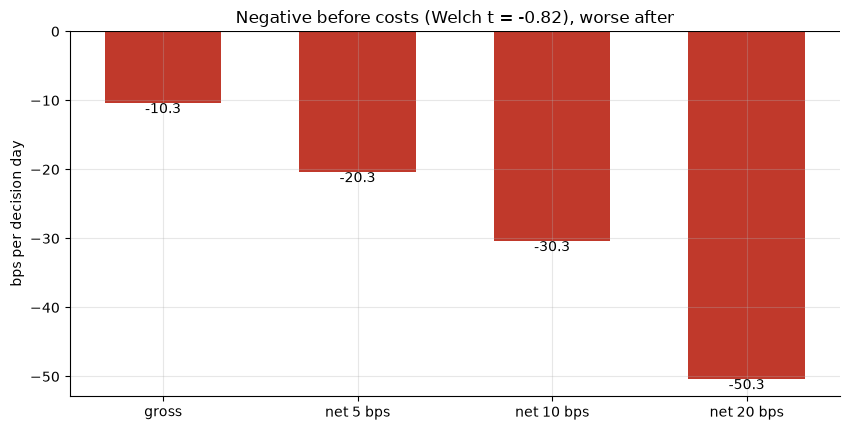

gross -10.3 -> net -20.3 / -30.3 / -50.3 bps  (t=-0.82);  worst day -13.3%


In [7]:
if HAVE_REAL:
    rows = [st.timer_capture(DF, cost_bps=cb) for cb in (5.0, 10.0, 20.0)]
    g = rows[0]['gross_bps']; n5, n10, n20 = (rows[0]['net_bps'], rows[1]['net_bps'],
                                              rows[2]['net_bps'])
    tv, worst = rows[0]['welch_t'], rows[0]['worst_day_pct']
else:
    g, n5, n10, n20 = R['tm_gross'], R['tm_net5'], R['tm_net10'], R['tm_net20']
    tv, worst = R['tm_t'], R['tm_worst']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['gross','net 5 bps','net 10 bps','net 20 bps'], [g, n5, n10, n20],
       color=[RED, RED, RED, RED], width=.6)
for i,v in enumerate([g, n5, n10, n20]): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('bps per decision day')
ax.set_title(f'Negative before costs (Welch t = {tv:+.2f}), worse after')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f} -> net {n5:+.1f} / {n10:+.1f} / {n20:+.1f} bps  '
      f'(t={tv:+.2f});  worst day {worst:+.1f}%')

> 💡 In plain words: **-10.3 bps per event, gross** — already negative before a single basis point of cost, at Welch *t* = -0.82 (nowhere near significant either way), with a **-13.3%** worst single day. H₅ is not supported. Structurally: the range bump is a genuine event premium, but it belongs in the **options** on decision day — exactly where it's already marked up — not in a directional bet on the underlying ETF.

### 4g · Faithful-engine & power control — we know the truth here

Synthetic i.i.d.-return world, scheduled pseudo-decisions every 22nd business day (≈ the 6-week cadence), TUNABLE planted drift. The null (drift = 0) is checked over **20 seeds** — never a single stream.

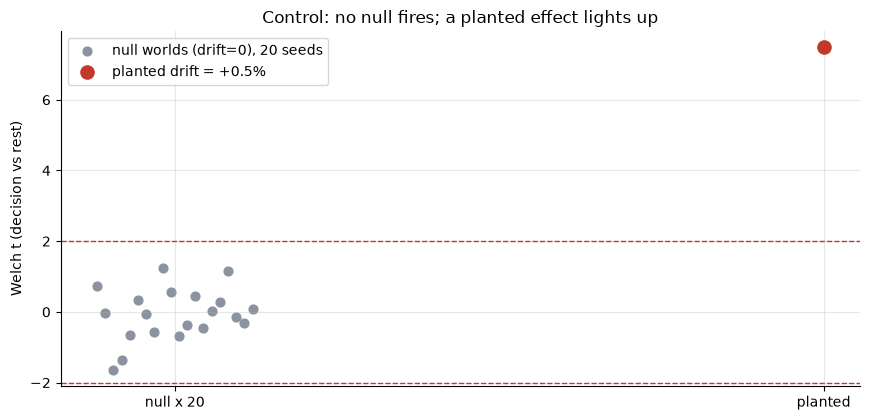

null: mean t = -0.07 (sd 0.73), |t|>=2 in 0/20 seeds  |  planted t = +7.48


In [8]:
null_ts = []
for s_ in range(20):
    close, dec = data.synthetic_world(drift=0.0, seed=645 + s_)
    null_ts.append(st.synthetic_detect(close, dec)['welch_t'])
null_ts = np.asarray(null_ts)
close, dec = data.synthetic_world(drift=0.005, seed=645)
planted_t = st.synthetic_detect(close, dec)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (drift=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted drift = +0.5%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (decision vs rest)')
ax.set_title('Control: no null fires; a planted effect lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.07 (sd 0.73) and **never** crosses the bar; a planted 0.5% drift reads t = 7.48. The machinery is unbiased — the real-tape null (H₁) is a genuine absence, not a blind spot. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — real on the vol: FEZ range **1.19×** baseline, Welch t = **2.66**, NW t = **2.83**, placebo p = **0.0008**. None on the drift: Welch t = **-0.82**, NW t = **-0.83**, placebo p = **0.345**; EURUSD reaction null (*t* = 0.65); no pre-meeting run-up (*t* = 0.54). Caveat named: neither era split alone clears *t* = 2 on the range bump (1.70 / 1.65).
- **Tradability `MIRAGE`** — the timer rule is negative **gross**, before costs (-10.3 bps/event, *t* = -0.82), with a -13.3% worst day. There is no drift to harvest and the vol elevation is not a directional edge.
- **"Louder, not more directional"? `CONFIRMED`** — the range bump is real and three-ways robust; direction (FEZ) and the FX cross-check (EURUSD) are both statistically indistinguishable from an ordinary Thursday.

## 6 · Going further

- **The general object is the announcement premium, again.** This is the third time this desk finds the same shape — real vol elevation, null signed drift — on a scheduled central-bank or cartel decision ([637-fomc-vol-crush](../../637-fomc-vol-crush/), [606-opec-announcement-effect](../../606-opec-announcement-effect/), now the ECB). The professional expression lives in the **options** on decision day, not in a directional bet on the underlying.
- **Why the FX cross-check came up empty is itself informative:** EURUSD is one of the most liquid, most efficiently-traded pairs on earth, with a deep options market pricing every scheduled central-bank date years ahead. If any market should show *zero* extra reaction to a fully-anticipated event, it's this one — measuring the analogous intraday (not daily) reaction is the natural sequel.
- **Dedup map:** [637-fomc-vol-crush](../../637-fomc-vol-crush/) (the Fed's own vol crush), [517-pre-fomc-drift](../../517-pre-fomc-drift/) / [67-fed-drift](../../67-fed-drift/) (the Fed's pre-meeting equity drift and its decay), [135-fomc-cycle](../../135-fomc-cycle/) (Fed week-parity returns), [322-fomc-blackout](../../322-fomc-blackout/) (the Fed's pre-meeting window), [606-opec-announcement-effect](../../606-opec-announcement-effect/) (the closest sibling in *shape* — same Real-vol/None-drift verdict, different institution and asset class), [314-jackson-hole](../../314-jackson-hole/) (an unscheduled-content central-bank speech, not a rate decision).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*